In [1]:
import sys
!{sys.executable} -m pip install emoji

In [2]:
import re
import nltk
from nltk.tokenize import word_tokenize
import emoji
import numpy as np

from utils2 import get_dict

nltk.download('punkt')  # download pre-trained Punkt tokenizer for English

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Data preparation 

## Cleaning and tokenization 

In [3]:
corpus = 'Who ❤️ "word embeddings" in 2020? I do!!!'

In [4]:
print (f'Corpus: {corpus} ')
data = re.sub(r'[,!?;-]+','.', corpus)
print (f'After cleaning punctuation: {data}') 

Corpus: Who ❤️ "word embeddings" in 2020? I do!!! 
After cleaning punctuation: Who ❤️ "word embeddings" in 2020. I do.


In [5]:
print(f'Initial string: {data}')
data = nltk.word_tokenize(data)
print('After tokenization: {data}')

Initial string: Who ❤️ "word embeddings" in 2020. I do.
After tokenization: {data}


In [6]:
print('Initial list of tokens: {data}')
data = [    ch.lower() for ch in data
            if ch.isalpha()
            or ch == '.'
            or emoji.is_emoji(ch) # keeps emojis.
        ]
print (f'After cleaning {data}')

Initial list of tokens: {data}
After cleaning ['who', '❤️', 'word', 'embeddings', 'in', '.', 'i', 'do', '.']


In [7]:
def tokenize (corpus):
    data = re.sub(r'[,!?;-]+','.', corpus)
    data = nltk.word_tokenize(data) # tokenize strings to words
    data = [    ch.lower() for ch in data
            if ch.isalpha()
            or ch == '.'
            or emoji.is_emoji(ch) # keeps emojis.
        ]
    return data


In [8]:
corpus = 'I am happy because I am learning'
print(f'Corpus:  {corpus}')
words = tokenize(corpus)
print(f'Words (tokens):  {words}')

Corpus:  I am happy because I am learning
Words (tokens):  ['i', 'am', 'happy', 'because', 'i', 'am', 'learning']


## Sliding window of words

In [9]:
def get_windows (words, C = 2):
    i = C
    while i < len (words) - C:
        center_word = words[i]
        context_word = words[i-C : i] + words[i+1 : i+C+1 ]
        yield context_word,center_word #using yield instead of return. return immediately exit the function, 
                                       #yield, pauses the function, sends back a value temporarily, and allows the function to continue later from the same point.
        i +=1

In [10]:
corpus = 'I am happy because I am learning'
words = tokenize(corpus)

print (tokenize(corpus))

['i', 'am', 'happy', 'because', 'i', 'am', 'learning']


## Transforming words into vectors 

### Mapping words to indices and indices to words

In [11]:
# Get word2Ind and Ind2word dicts for the tokenized corpus
word2Ind, In2word = get_dict (words)

In [12]:
word2Ind

{'am': 0, 'because': 1, 'happy': 2, 'i': 3, 'learning': 4}

In [13]:
print("Index of the word 'i':  ",word2Ind['i'])

Index of the word 'i':   3


In [14]:
# print value for the key '2' within In2word dictionary 
print("Word which has index 2: ",In2word[2])

Word which has index 2:  happy


In [ ]:
In2word

In [15]:
print("word which has index 2:",In2word[2] )

word which has index 2: happy


In [16]:
# Save length of word2Ind dict into the 'V' variable
V = len(word2Ind)

print("Size of vocabulary: ",V) 

Size of vocabulary:  5


### Getting one-hot word vectors


In [17]:
# Save index of word 'happy' into the 'n' Variable
n =word2Ind['happy']
n


2

In [18]:
center_word_vector = np.zeros(V) # vector filled with zeros with the same size as the vocabulary 
center_word_vector


array([0., 0., 0., 0., 0.])

In [19]:
len(center_word_vector) == V # Assert that vocab length and center_word_vector length is the same

True

In [20]:
# Replace element number 'n' with a 1
center_word_vector[n] = 1


In [21]:
center_word_vector

array([0., 0., 1., 0., 0.])

In [22]:
# all in 1 function
def word_to_one_hot_vector (word, word2Ind, V):
    one_hot_vector = np.zeros(V)
    one_hot_vector[word2Ind[word]] = 1
    return one_hot_vector

In [23]:
word_to_one_hot_vector('happy', word2Ind, V)

array([0., 0., 1., 0., 0.])

In [24]:
word_to_one_hot_vector('learning', word2Ind, V)

array([0., 0., 0., 0., 1.])

### Getting  context word vectors


In [26]:
context_words = ['i', 'am', 'because', 'i']

In [27]:
context_words_vectors = [word_to_one_hot_vector(w, word2Ind, V) for w in context_words]
context_words_vectors

[array([0., 0., 0., 1., 0.]),
 array([1., 0., 0., 0., 0.]),
 array([0., 1., 0., 0., 0.]),
 array([0., 0., 0., 1., 0.])]

In [28]:
np.mean(context_words_vectors, axis=0)

array([0.25, 0.25, 0.  , 0.5 , 0.  ])

In [ ]:
# All in one function
def context_words_to_vector (context_words, word2Ind, V):
    context_words_vectors = [word_to_one_hot_vector(w ,word2Ind,V) for w in context_words ] 
    context_words_vectors = np.mean(context_words_vectors, axis=0)
    return context_words_vectors

In [29]:
context_words_to_vector(['i', 'am', 'because', 'i'], word2Ind, V)

array([0.25, 0.25, 0.  , 0.5 , 0.  ])

In [30]:
context_words_to_vector(['am', 'happy', 'i', 'am'], word2Ind, V)

array([0.5 , 0.  , 0.25, 0.25, 0.  ])

## Building the training set

In [31]:
words

['i', 'am', 'happy', 'because', 'i', 'am', 'learning']

In [32]:
# Print vectors associated to center and context words for corpus
for context_words, center_word in get_windows(words, 2):
    print(f'Context words:  {context_words} -> {context_words_to_vector(context_words, word2Ind, V)}')
    print(f'Center word:  {center_word} -> {word_to_one_hot_vector(center_word, word2Ind, V)}')
    print()

Context words:  ['i', 'am', 'because', 'i'] -> [0.25 0.25 0.   0.5  0.  ]
Center word:  happy -> [0. 0. 1. 0. 0.]

Context words:  ['am', 'happy', 'i', 'am'] -> [0.5  0.   0.25 0.25 0.  ]
Center word:  because -> [0. 1. 0. 0. 0.]

Context words:  ['happy', 'because', 'am', 'learning'] -> [0.25 0.25 0.25 0.   0.25]
Center word:  i -> [0. 0. 0. 1. 0.]



In [33]:
# Define the generator function associated to center and context words for corpus using the generator function
def get_training_example (words, C, word2Ind, V):
    for context_words, center_word in  get_windows (words, C):
        yield context_words_to_vector(context_words, word2Ind, V), word_to_one_hot_vector(center_word, word2Ind, V)

In [34]:
# Print vectors associated to center and context words for corpus using the generator function
for context_words_vector, center_word_vector in get_training_example(words, 2, word2Ind, V):
    print(f'Context words vector:  {context_words_vector}')
    print(f'Center word vector:  {center_word_vector}')
    print()

Context words vector:  [0.25 0.25 0.   0.5  0.  ]
Center word vector:  [0. 0. 1. 0. 0.]

Context words vector:  [0.5  0.   0.25 0.25 0.  ]
Center word vector:  [0. 1. 0. 0. 0.]

Context words vector:  [0.25 0.25 0.25 0.   0.25]
Center word vector:  [0. 0. 0. 1. 0.]



# The continuous bag-of-words model 

The CBOW model is based on a neural network, the architecture of which looks like the figure below
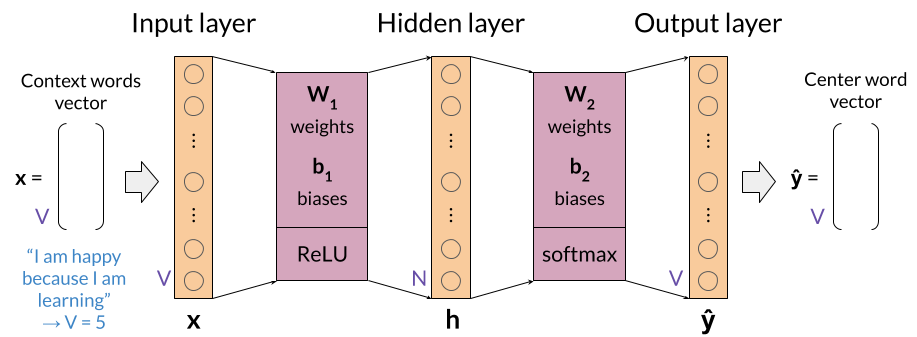
- The two activation functions used in the neural network.

- Forward propagation.

- Cross-entropy loss.

- Backpropagation.

- Gradient descent.

- Extracting the word embedding vectors from the weight matrices once the neural network has been trained.

## Activation functions

### ReLU

ReLU is used to calculate the values of the hidden layer, in the following formulas:

\begin{align}
 \mathbf{z_1} &= \mathbf{W_1}\mathbf{x} + \mathbf{b_1}  \tag{1} \\
 \mathbf{h} &= \mathrm{ReLU}(\mathbf{z_1})  \tag{2} \\
\end{align}


In [35]:
np.random.seed(10)
z_1 = 10*np.random.rand(5, 1)-5
z_1

array([[ 2.71320643],
       [-4.79248051],
       [ 1.33648235],
       [ 2.48803883],
       [-0.01492988]])

In [37]:
h = z_1.copy()
h[h<0] = 0 
h

array([[2.71320643],
       [0.        ],
       [1.33648235],
       [2.48803883],
       [0.        ]])

In [38]:
def relu (z):
    result = z.copy()
    result[result < 0] =  0
    return result


In [39]:
z = np.array([[-1.25459881], [ 4.50714306], [ 2.31993942], [ 0.98658484], [-3.4398136 ]])
relu(z)

array([[0.        ],
       [4.50714306],
       [2.31993942],
       [0.98658484],
       [0.        ]])

### Softmax

The second activation function that you need is softmax. This function is used to calculate the values of the output layer of the neural network, using the following formulas:

\begin{align}
 \mathbf{z_2} &= \mathbf{W_2}\mathbf{h} + \mathbf{b_2}   \tag{3} \\
 \mathbf{\hat y} &= \mathrm{softmax}(\mathbf{z_2})   \tag{4} \\
\end{align}

To calculate softmax of a vector $\mathbf{z}$, the $i$-th component of the resulting vector is given by:

$$ \textrm{softmax}(\textbf{z})_i = \frac{e^{z_i} }{\sum\limits_{j=1}^{V} e^{z_j} }  \tag{5} $$

In [40]:
z = np.array([9, 8, 11, 10, 8.5])

In [41]:
e_z = np.exp(z)
e_z


array([ 8103.08392758,  2980.95798704, 59874.1417152 , 22026.46579481,
        4914.7688403 ])

In [42]:
sum_e_z = np.sum(e_z)
e_z[0]/sum_e_z

np.float64(0.08276947985173956)

In [43]:
def softmax(z):
    e_z = np.exp(z)
    sum_e_z = np.sum(e_z)
    return e_z/sum_e_z

In [44]:
softmax([9, 8, 11, 10, 8.5])

array([0.08276948, 0.03044919, 0.61158833, 0.22499077, 0.05020223])

## Dimensions: 1-D arrays vs 2-D column vectors

In [45]:
V = 5 # Vocabulary size
x_array = np.zeros(V) # x_array is array of zeros with the same size as V
x_array

array([0., 0., 0., 0., 0.])

In [46]:
x_array.shape

(5,)

To perform matrix multiplication in the next steps, you actually need your column vectors to be represented as a matrix with one column. In numpy, this matrix is represented as a 2-dimensional array.

The easiest way to convert a 1D vector to a 2D column matrix is to set its .shape property to the number of rows and one column, as shown in the next cell.

In [47]:
x_column_vector = x_array.copy()
x_column_vector.shape = (V,1) # alternatively (x_array.shape[0], 1)
x_column_vector

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [48]:
x_column_vector.shape

(5, 1)

## Forward propagation

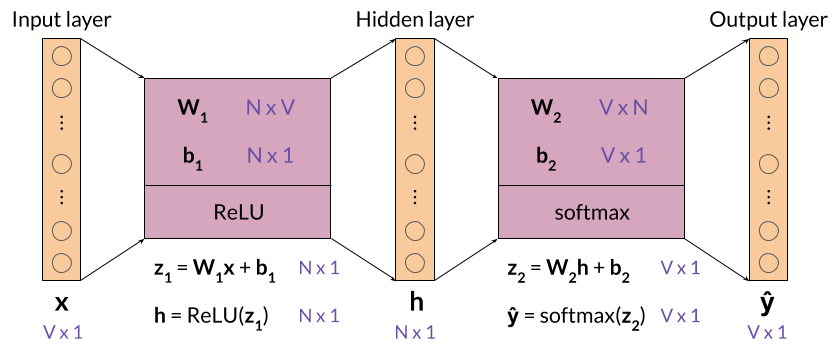
Set  𝑁
  equal to 3. Remember that  𝑁
  is a hyperparameter of the CBOW model that represents the size of the word embedding vectors, as well as the size of the hidden layer.

In [ ]:
N = 3 # Hyperparameter of the CBOW model that represent the size of the word embedding vectors, as well as the size of the hidden layer

V = 5 # Size of vocabulary in previous lecture notebooks

### Initialization of weights and biases

Before you start training the neural network, you need to initialize the weight matrices and bias vectors with random values.

In [50]:
# Define first matrix of weights
W1 = np.array([[ 0.41687358,  0.08854191, -0.23495225,  0.28320538,  0.41800106],
               [ 0.32735501,  0.22795148, -0.23951958,  0.4117634 , -0.23924344],
               [ 0.26637602, -0.23846886, -0.37770863, -0.11399446,  0.34008124]])

# Define second matrix of weights
W2 = np.array([[-0.22182064, -0.43008631,  0.13310965],
               [ 0.08476603,  0.08123194,  0.1772054 ],
               [ 0.1871551 , -0.06107263, -0.1790735 ],
               [ 0.07055222, -0.02015138,  0.36107434],
               [ 0.33480474, -0.39423389, -0.43959196]])

# Define first vector of biases
b1 = np.array([[ 0.09688219],
               [ 0.29239497],
               [-0.27364426]])

# Define second vector of biases
b2 = np.array([[ 0.0352008 ],
               [-0.36393384],
               [-0.12775555],
               [-0.34802326],
               [-0.07017815]])

In [51]:
print(f'V (vocabulary size): {V}')
print(f'N (embedding size / size of the hidden layer): {N}')
print(f'size of W1: {W1.shape} (NxV)')
print(f'size of b1: {b1.shape} (Nx1)')
print(f'size of W2: {W2.shape} (VxN)')
print(f'size of b2: {b2.shape} (Vx1)')

V (vocabulary size): 5
N (embedding size / size of the hidden layer): 3
size of W1: (3, 5) (NxV)
size of b1: (3, 1) (Nx1)
size of W2: (5, 3) (VxN)
size of b2: (5, 1) (Vx1)


### Training example

In [ ]:
training_examples = get_training_example(words, 2, word2Ind, V)
"""
get_training_examples, which uses the yield keyword, is known as a generator. When run, it builds an iterator, which is a special type of object that... 
you can iterate on (using a for loop for instance), to retrieve the successive values that the function generates.

In this case get_training_examples yields training examples, and iterating on training_examples will return the successive training examples.
"""

In [53]:
x_array, y_array = next(training_examples)

"""
next is another special keyword, which gets the next available value from an iterator. Here, you'll get the very first value, which is the first training example. If you run this cell again, you'll get the next value, and so on until the iterator runs out of values to return.

In this notebook next is used because you will only be performing one iteration of training
"""

"\nnext is another special keyword, which gets the next available value from an iterator. Here, you'll get the very first value, which is the first training example. If you run this cell again, you'll get the next value, and so on until the iterator runs out of values to return.\n\nIn this notebook next is used because you will only be performing one iteration of training\n"

In [54]:
# Context words vector
x_array

array([0.25, 0.25, 0.  , 0.5 , 0.  ])

In [55]:
# One hot vector of center word
y_array

array([0., 0., 1., 0., 0.])

In [56]:
# Convert vectors into matrices (2D arrays)
x = x_array.copy()

# Reshape x
x.shape = (V,1)

print (f'x:\n{x}\n')

y = y_array.copy()

y.shape = (V,1)

print (f'x:\n{y}\n')

x:
[[0.25]
 [0.25]
 [0.  ]
 [0.5 ]
 [0.  ]]

x:
[[0.]
 [0.]
 [1.]
 [0.]
 [0.]]



### Values of the hidden layer

Now we have initialized all the variables that  need for forward propagation, you can calculate the values of the hidden layer using the following formulas:

\begin{align}
 \mathbf{z_1} = \mathbf{W_1}\mathbf{x} + \mathbf{b_1}  \tag{1} \\
 \mathbf{h} = \mathrm{ReLU}(\mathbf{z_1})  \tag{2} \\
\end{align}

In [57]:
# z1 is the values of the first hidden layer before applying the ReLU function

z1 = np.dot(W1, x) + b1
z1

array([[ 0.36483875],
       [ 0.63710329],
       [-0.3236647 ]])

In [58]:
# compute h (z1 after applying the ReLU function)
h = relu(z1)

h

array([[0.36483875],
       [0.63710329],
       [0.        ]])

### Values of the output layer

Here are the formulas needed to calculate the values of the output layer, represented by the vector $\mathbf{\hat y}$:

\begin{align}
 \mathbf{z_2} &= \mathbf{W_2}\mathbf{h} + \mathbf{b_2}   \tag{3} \\
 \mathbf{\hat y} &= \mathrm{softmax}(\mathbf{z_2})   \tag{4} \\
\end{align}

In [59]:
# z2 is the values of the output layer before applying the softmax function

z2 = np.dot(W2, h) + b2
z2

array([[-0.31973737],
       [-0.28125477],
       [-0.09838369],
       [-0.33512159],
       [-0.19919612]])

In [60]:
# compute y_hat (z2 after applying the softmax function)

y_hat = softmax(z2)
y_hat

array([[0.18519074],
       [0.19245626],
       [0.23107446],
       [0.18236353],
       [0.20891502]])

## Cross-entropy loss

> Remember that you are working on a single training example, not on a batch of examples, which is why you are using *loss* and not *cost*, which is the generalized form of loss.

In [61]:
y_hat

array([[0.18519074],
       [0.19245626],
       [0.23107446],
       [0.18236353],
       [0.20891502]])

In [62]:
y

array([[0.],
       [0.],
       [1.],
       [0.],
       [0.]])

The formula for cross-entropy loss is:

$$ J=-\sum\limits_{k=1}^{V}y_k\log{\hat{y}_k} \tag{6}$$


In [63]:
def cross_entropy_loss(y_predicted, y_actual):
    # Fill the loss variable with your code
    
    
    """    
    loss = 0
    for y_hat , y in zip(y_predicted, y_actual): 
        loss =  loss + (y * np.log(y_hat))
    return -loss
    """
    
    

    loss = np.sum(-np.log(y_predicted) * y_actual)
    return loss

In [ ]:
cross_entropy_loss(y_hat, y)

np.float64(1.4650152923611106)

## Back propagation



The backpropagation formulas.

\begin{align}
 \frac{\partial J}{\partial \mathbf{W_1}} &= \rm{ReLU}\left ( \mathbf{W_2^\top} (\mathbf{\hat{y}} - \mathbf{y})\right )\mathbf{x}^\top \tag{7}\\
 \frac{\partial J}{\partial \mathbf{W_2}} &= (\mathbf{\hat{y}} - \mathbf{y})\mathbf{h^\top} \tag{8}\\
 \frac{\partial J}{\partial \mathbf{b_1}} &= \rm{ReLU}\left ( \mathbf{W_2^\top} (\mathbf{\hat{y}} - \mathbf{y})\right ) \tag{9}\\
 \frac{\partial J}{\partial \mathbf{b_2}} &= \mathbf{\hat{y}} - \mathbf{y} \tag{10}
\end{align}

**Calculate the partial derivative of the loss function with respect to $\mathbf{b_2}$, and store the result in `grad_b2`.**

$$\frac{\partial J}{\partial \mathbf{b_2}} = \mathbf{\hat{y}} - \mathbf{y} \tag{10}$$

In [65]:
# compute vector with partial derivatives of loss function with respect to b2

grad_b2 = y_hat - y

grad_b2


array([[ 0.18519074],
       [ 0.19245626],
       [-0.76892554],
       [ 0.18236353],
       [ 0.20891502]])

**partial derivative of the loss function with respect to $\mathbf{W_2}$, and store the result in `grad_W2`.**

$$\frac{\partial J}{\partial \mathbf{W_2}} = (\mathbf{\hat{y}} - \mathbf{y})\mathbf{h^\top} \tag{8}$$

In [66]:
# compute matrix with partial derivatives of loss function with respect to W2

grad_W2 = np.dot(y_hat - y, h.T)

grad_W2

array([[ 0.06756476,  0.11798563,  0.        ],
       [ 0.0702155 ,  0.12261452,  0.        ],
       [-0.28053384, -0.48988499,  0.        ],
       [ 0.06653328,  0.1161844 ,  0.        ],
       [ 0.07622029,  0.13310045,  0.        ]])

In [67]:
# compute matrix with partial derivatives of loss function with respect to b1

grad_b1 = relu(np.dot(W2.T, y_hat - y))

In [68]:
# compute matrix with partial derivatives of loss function with respect to W1

grad_W1 =  np.dot(relu(np.dot(W2.T, y_hat - y)), x.T)
grad_W1

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.04261464, 0.04261464, 0.        , 0.08522929, 0.        ]])

In [69]:
print(f'V (vocabulary size): {V}')
print(f'N (embedding size / size of the hidden layer): {N}')
print(f'size of grad_W1: {grad_W1.shape} (NxV)')
print(f'size of grad_b1: {grad_b1.shape} (Nx1)')
print(f'size of grad_W2: {grad_W2.shape} (VxN)')
print(f'size of grad_b2: {grad_b2.shape} (Vx1)')

V (vocabulary size): 5
N (embedding size / size of the hidden layer): 3
size of grad_W1: (3, 5) (NxV)
size of grad_b1: (3, 1) (Nx1)
size of grad_W2: (5, 3) (VxN)
size of grad_b2: (5, 1) (Vx1)


## Gradient descent 


Gradient descent update the weights and biases by subtracting $\alpha$ times the gradient from the original matrices and vectors, using the following formulas.

\begin{align}
 \mathbf{W_1} &:= \mathbf{W_1} - \alpha \frac{\partial J}{\partial \mathbf{W_1}} \tag{11}\\
 \mathbf{W_2} &:= \mathbf{W_2} - \alpha \frac{\partial J}{\partial \mathbf{W_2}} \tag{12}\\
 \mathbf{b_1} &:= \mathbf{b_1} - \alpha \frac{\partial J}{\partial \mathbf{b_1}} \tag{13}\\
 \mathbf{b_2} &:= \mathbf{b_2} - \alpha \frac{\partial J}{\partial \mathbf{b_2}} \tag{14}\\
\end{align}

In [70]:
# Define alpha
alpha = 0.03


In [71]:
# Compute updated W1
W1_new = W1 - alpha * grad_W1

In [72]:
print('old value of W1:')
print(W1)
print()
print('new value of W1:')
print(W1_new)

old value of W1:
[[ 0.41687358  0.08854191 -0.23495225  0.28320538  0.41800106]
 [ 0.32735501  0.22795148 -0.23951958  0.4117634  -0.23924344]
 [ 0.26637602 -0.23846886 -0.37770863 -0.11399446  0.34008124]]

new value of W1:
[[ 0.41687358  0.08854191 -0.23495225  0.28320538  0.41800106]
 [ 0.32735501  0.22795148 -0.23951958  0.4117634  -0.23924344]
 [ 0.26509758 -0.2397473  -0.37770863 -0.11655134  0.34008124]]


**Now calculate the new values of $\mathbf{W_2}$ (to be stored in `W2_new`), $\mathbf{b_1}$ (in `b1_new`), and $\mathbf{b_2}$ (in `b2_new`).**

\begin{align}
 \mathbf{W_2} &:= \mathbf{W_2} - \alpha \frac{\partial J}{\partial \mathbf{W_2}} \tag{12}\\
 \mathbf{b_1} &:= \mathbf{b_1} - \alpha \frac{\partial J}{\partial \mathbf{b_1}} \tag{13}\\
 \mathbf{b_2} &:= \mathbf{b_2} - \alpha \frac{\partial J}{\partial \mathbf{b_2}} \tag{14}\\
\end{align}

In [74]:
# Compute updated W2
W2_new = W2 - alpha * grad_W2

# Compute updated b1
b1_new = b1 - alpha * grad_b1

# Compute updated b2
b2_new = b2 - alpha * grad_b2


print('W2_new')
print(W2_new)
print()
print('b1_new')
print(b1_new)
print()
print('b2_new')
print(b2_new)

W2_new
[[-0.22384758 -0.43362588  0.13310965]
 [ 0.08265956  0.0775535   0.1772054 ]
 [ 0.19557112 -0.04637608 -0.1790735 ]
 [ 0.06855622 -0.02363691  0.36107434]
 [ 0.33251813 -0.3982269  -0.43959196]]

b1_new
[[ 0.09688219]
 [ 0.29239497]
 [-0.27875802]]

b2_new
[[ 0.02964508]
 [-0.36970753]
 [-0.10468778]
 [-0.35349417]
 [-0.0764456 ]]
